# Finding Optimal Weights w* — Two Methods

We want to minimize the MSE cost function:

$$J(\mathbf{w}) = \frac{1}{N} \|\mathbf{Xw} - \mathbf{y}\|_2^2$$

There are two ways to find the **w*** that makes J(w) as small as possible:

| Method | Idea | Best for |
|---|---|---|
| **Normal Equation** | Solve directly with linear algebra — one shot, exact answer | Small datasets, few features |
| **Gradient Descent** | Iteratively walk downhill on the cost surface | Large datasets, neural networks |

Both methods will find the **same w*** — they just take different routes.

## Cell 1 — Method 1: Normal Equation

### The Formula
$$\mathbf{w^*} = (\mathbf{X}^T\mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

### How it's derived
1. Take the gradient of J(w) and set it to zero: $\nabla J(\mathbf{w}) = \frac{2}{N} X^T(Xw - y) = 0$
2. The **2/N** disappears (multiplying both sides by N/2 — zero stays zero)
3. Rearrange: $X^TXw = X^Ty$
4. Multiply both sides by $(X^TX)^{-1}$ → **w\* = (XᵀX)⁻¹ Xᵀy**

### What each part means
- **Xᵀy** — how much each feature correlates with the target
- **(XᵀX)⁻¹** — normalizes by the feature spread (inverse of feature covariance)
- Together: one matrix multiplication gives the **exact** optimal weights

> **No iteration needed** — plug in your data, compute once, done.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────────────────
np.random.seed(0)
X_raw = 2 * np.random.rand(50, 1)               # 50 samples, 1 feature
y     = 3 * X_raw + 4 + np.random.randn(50, 1)  # true: w=3, bias=4
X     = np.hstack([np.ones((50, 1)), X_raw])     # add bias column of 1s

# ── Normal Equation: w* = (XᵀX)⁻¹ Xᵀy ───────────────────────────
w_ne = np.linalg.inv(X.T @ X) @ X.T @ y
print("Normal Equation  → bias={:.3f}, w={:.3f}".format(w_ne[0,0], w_ne[1,0]))
print("(True values     → bias=4.000, w=3.000)")

Normal Equation  → bias=3.993, w=2.846
(True values     → bias=4.000, w=3.000)


## Cell 2 — Method 2: Gradient Descent

### The Two Steps

**Step 1 — Compute the gradient** (how much does each weight contribute to the error?):
$$\nabla J(\mathbf{w}) = \frac{2}{N} \mathbf{X}^T (\mathbf{Xw} - \mathbf{y})$$

- $(\mathbf{Xw} - \mathbf{y})$ → current prediction errors
- $\mathbf{X}^T(\mathbf{Xw}-\mathbf{y})$ → redistribute errors back to each weight (who's to blame?)
- $\frac{2}{N}$ → scaling constant from differentiating the squared term

**Step 2 — Update rule** (move opposite to gradient to reduce error):
$$\mathbf{w}_{new} = \mathbf{w}_{old} - \alpha \cdot \nabla J(\mathbf{w})$$

Substituting Step 1 into Step 2 gives the **full update**:
$$\mathbf{w}_{new} = \mathbf{w}_{old} - \alpha \cdot \frac{2}{N} \mathbf{X}^T (\mathbf{Xw}_{old} - \mathbf{y})$$

- The **minus sign** is the key: gradient points uphill → subtract it → move downhill → cost drops
- **α (learning rate)** controls step size — too large: overshoot; too small: slow convergence
- Repeat until gradient ≈ 0 (flat ground = minimum reached)

> **One iteration in plain English:** compute errors → blame each weight → nudge weights in opposite direction → repeat.

Gradient Descent → bias=3.987, w=2.851
(True values     → bias=4.000, w=3.000)


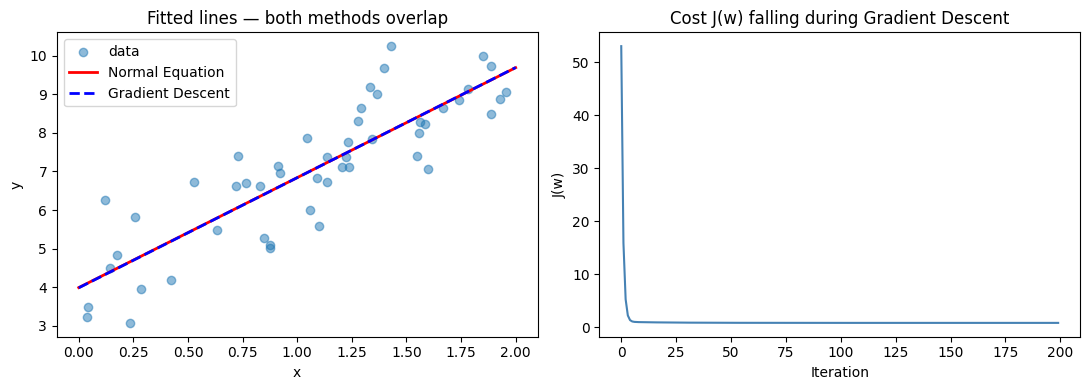

In [2]:
# ── Gradient Descent: w_new = w_old - α · (2/N) · Xᵀ(Xw - y) ────
w     = np.zeros((2, 1))  # start weights at zero
alpha = 0.1               # learning rate
N     = len(X)            # number of samples
costs = []                # track cost per iteration

for _ in range(200):
    error = X @ w - y               # Step 1a: prediction errors (Xw - y)
    grad  = (2/N) * X.T @ error     # Step 1b: gradient ∇J = (2/N) Xᵀ(Xw-y)
    w     = w - alpha * grad        # Step 2:  update w_new = w_old - α∇J
    costs.append((error**2).mean()) # track J(w) = mean squared error

print("Gradient Descent → bias={:.3f}, w={:.3f}".format(w[0,0], w[1,0]))
print("(True values     → bias=4.000, w=3.000)")

# ── Plot: fitted lines + cost curve ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

x_line = np.array([[1, 0], [1, 2]])
ax1.scatter(X_raw, y, alpha=0.5, label='data')
ax1.plot([0,2], x_line @ w_ne, 'r-',  lw=2, label='Normal Equation')
ax1.plot([0,2], x_line @ w,    'b--', lw=2, label='Gradient Descent')
ax1.set(xlabel='x', ylabel='y', title='Fitted lines — both methods overlap')
ax1.legend()

ax2.plot(costs, color='steelblue')
ax2.set(xlabel='Iteration', ylabel='J(w)', title='Cost J(w) falling during Gradient Descent')

plt.tight_layout()
plt.show()